# Ablation Study — WIRE Graph Transformer
**Configs compared (5 seeds each):**
1. **Baseline LSTM** — no graph structure
2. **v6: Sector-only WIRE** — GICS sector graph, M=16
3. **v8: Multi-relational WIRE** — Sector + Supply Chain (adaptive allocation, M=16)

All outputs saved to Google Drive `output/v6/` and `output/v8/`.

In [1]:
from google.colab import drive
drive.mount("/content/drive")
import os
for v in ["v6", "v8"]:
    os.makedirs(f"/content/drive/MyDrive/3106_Projects/Projects/output/{v}", exist_ok=True)

Mounted at /content/drive


In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.sparse.csgraph import laplacian
from scipy.linalg import eigh
from scipy.stats import spearmanr, ttest_rel
import json, warnings
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 1. Data Pipeline

In [3]:
crsp = pd.read_csv("<Enter your data path here>/qf0egyr4ffi0pszj.csv", parse_dates=["DlyCalDt"])
crsp = crsp.sort_values(["PERMNO", "DlyCalDt"]).reset_index(drop=True)
compustat = pd.read_csv("<Enter your data path here>/gg3axrtvut5hi5hh.csv", parse_dates=["datadate"])
compustat = compustat.rename(columns={"LPERMNO": "PERMNO"})
print(f"CRSP: {crsp.shape} | Compustat: {compustat.shape}")

CRSP: (1768234, 18) | Compustat: (27236, 19)


In [4]:
# Stock filtering
date_range = crsp["DlyCalDt"].nunique()
stock_counts = crsp.groupby("PERMNO")["DlyCalDt"].count()
valid_permnos = stock_counts[stock_counts >= date_range * 0.8].index
sector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsubind"]
gsector_map = compustat.drop_duplicates("PERMNO", keep="last").set_index("PERMNO")["gsector"]
valid_permnos = valid_permnos[valid_permnos.isin(sector_map.index)]
avg_vol = crsp[crsp["PERMNO"].isin(valid_permnos)].groupby("PERMNO")["DlyVol"].mean()
top_permnos = sorted(avg_vol.nlargest(100).index.tolist())
crsp_sub = crsp[crsp["PERMNO"].isin(top_permnos)].copy()
permno_to_idx = {p: i for i, p in enumerate(top_permnos)}
N_STOCKS = len(top_permnos)
sectors = np.array([gsector_map.get(p, -1) for p in top_permnos])
print(f"Universe: {N_STOCKS} stocks")

Universe: 100 stocks


In [5]:
# Feature engineering
def build_feature_matrix(df, permnos, p2i):
    dates = sorted(df["DlyCalDt"].unique())
    T, N = len(dates), len(permnos)
    feat = np.full((T, N, 6), np.nan, dtype=np.float32)
    df = df.copy()
    df["_t"] = df["DlyCalDt"].map({d: t for t, d in enumerate(dates)})
    df["_n"] = df["PERMNO"].map(p2i)
    df = df.dropna(subset=["_t", "_n"])
    t, n = df["_t"].astype(int).values, df["_n"].astype(int).values
    c = df["DlyPrc"].values.astype(np.float32)
    cs = np.where(c == 0, 1.0, c)
    feat[t, n, 0] = df["DlyOpen"].values / cs
    feat[t, n, 1] = df["DlyHigh"].values / cs
    feat[t, n, 2] = df["DlyLow"].values / cs
    feat[t, n, 3] = c
    feat[t, n, 4] = np.log1p(df["DlyVol"].values)
    feat[t, n, 5] = df["DlyRet"].values
    return feat, dates

features, dates = build_feature_matrix(crsp_sub, top_permnos, permno_to_idx)

FUND_FEATURES = ["roe", "leverage", "profit_margin", "log_assets"]
fund = compustat[["PERMNO", "datadate", "rdq", "atq", "ceqq", "niq"]].copy()
fund["datadate"] = pd.to_datetime(fund["datadate"])
fund["rdq"] = pd.to_datetime(fund["rdq"])
fund["avail_date"] = fund["rdq"].fillna(fund["datadate"] + pd.Timedelta(days=45))
def safe_ratio(num, denom, clip=10):
    return (num / denom.replace(0, np.nan)).clip(-clip, clip)
fund["roe"] = safe_ratio(fund["niq"], fund["ceqq"])
fund["leverage"] = safe_ratio(fund["atq"], fund["ceqq"])
fund["profit_margin"] = safe_ratio(fund["niq"], fund["atq"])
fund["log_assets"] = np.log1p(fund["atq"].clip(lower=0))

def merge_fundamentals(feat, dates, permnos, p2i, fund_df):
    T, N, F_old = feat.shape
    F_new = len(FUND_FEATURES)
    ff = np.full((T, N, F_new), np.nan, dtype=np.float32)
    for p in permnos:
        ni = p2i[p]
        sf = fund_df[fund_df["PERMNO"] == p].sort_values("avail_date")
        for _, r in sf.iterrows():
            for t, d in enumerate(dates):
                if d >= r["avail_date"]:
                    ff[t, ni, :] = [r[c] for c in FUND_FEATURES]
    for n in range(N):
        for f in range(F_new):
            lv = np.nan
            for t in range(T):
                if not np.isnan(ff[t, n, f]): lv = ff[t, n, f]
                else: ff[t, n, f] = lv
    return np.concatenate([feat, ff], axis=2)

features = merge_fundamentals(features, dates, top_permnos, permno_to_idx, fund)
print(f"Features: {features.shape}")

Features: (2766, 100, 10)


## 2. Graph Construction & Spectral Coordinates

In [6]:
# Sector graph
def build_adjacency(labels):
    L = labels.reshape(-1, 1)
    A = ((L == L.T) & (L != -1)).astype(np.float32)
    np.fill_diagonal(A, 0)
    return A

A_sector = build_adjacency(sectors)
n_sec = int(A_sector.sum() / 2)
print(f"Sector: {n_sec} edges, density={n_sec/(N_STOCKS*(N_STOCKS-1)/2):.4f}")

# Supply chain graph
comp = compustat.drop_duplicates("PERMNO", keep="last")
gvkey_to_permno = dict(zip(comp["GVKEY"].astype(int), comp["PERMNO"].astype(int)))
permno_to_gvkey = {v: k for k, v in gvkey_to_permno.items()}
universe_gvkeys = set(permno_to_gvkey.get(p) for p in top_permnos if p in permno_to_gvkey)

sc = pd.read_csv("<Enter your data path here>/supplychain_segments.csv")
sc["gvkey"] = sc["gvkey"].astype(int)
sc_in = sc[sc["gvkey"].isin(universe_gvkeys)].copy()
ticker_df = crsp_sub.drop_duplicates("PERMNO", keep="last")[["PERMNO", "Ticker"]].dropna()
ticker_to_permno = dict(zip(ticker_df["Ticker"].str.upper(), ticker_df["PERMNO"].astype(int)))

A_supply = np.zeros((N_STOCKS, N_STOCKS), dtype=np.float32)
for _, row in sc_in.iterrows():
    sp = gvkey_to_permno.get(int(row["gvkey"]))
    if sp not in permno_to_idx: continue
    cn = str(row["cnms"]).upper().strip()
    for tk, pno in ticker_to_permno.items():
        if tk in cn or cn in tk:
            if pno in permno_to_idx and pno != sp:
                i, j = permno_to_idx[sp], permno_to_idx[pno]
                A_supply[i, j] = 1.0; A_supply[j, i] = 1.0

n_sup = int(A_supply.sum() / 2)
print(f"Supply chain: {n_sup} edges, density={n_sup/(N_STOCKS*(N_STOCKS-1)/2):.4f}")
A_graph = A_sector  # for attention analysis

Sector: 541 edges, density=0.1093
Supply chain: 310 edges, density=0.0626


v6: (100, 16), gap=-0.0000
v8 allocation: Sector=9d, Supply=7d
v8: (100, 16)


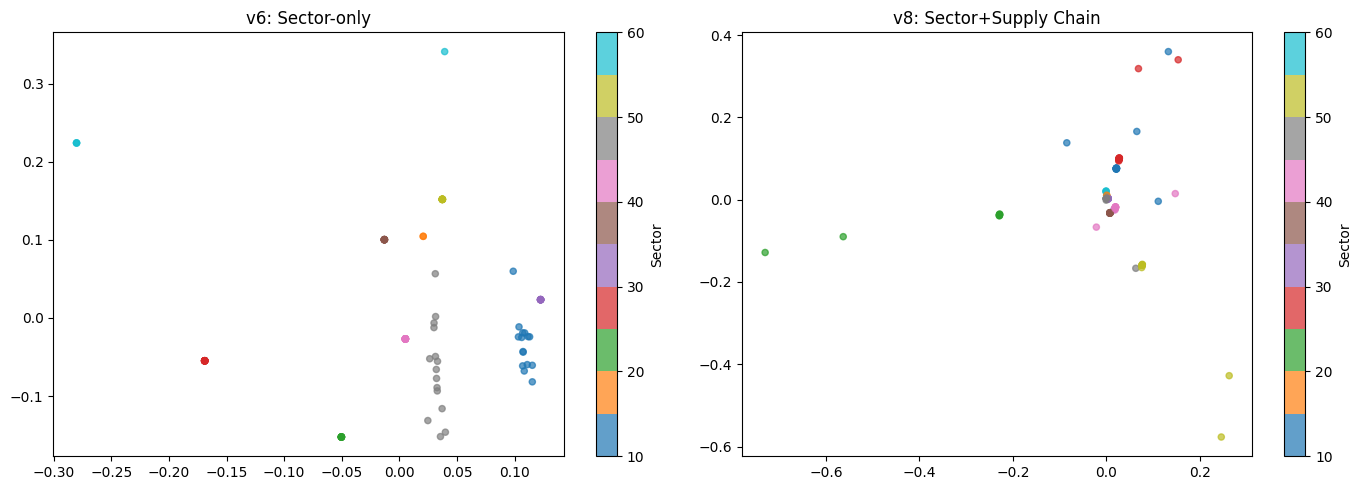

In [7]:
# Spectral coordinates
M_SPECTRAL = 16

# v6: sector-only
L_sec = laplacian(A_sector, normed=True)
evals_sec, evecs_sec = eigh(L_sec)
spec_v6 = evecs_sec[:, 1:M_SPECTRAL+1].astype(np.float32)
print(f"v6: {spec_v6.shape}, gap={evals_sec[1]:.4f}")

# v8: adaptive allocation
def spectral_energy(A):
    if A.sum() == 0: return 0
    return eigh(laplacian(A, normed=True), eigvals_only=True)[1:].sum()

e_sec, e_sup = spectral_energy(A_sector), spectral_energy(A_supply)
m_sec = max(2, round(e_sec / (e_sec + e_sup) * M_SPECTRAL))
m_sup = M_SPECTRAL - m_sec
print(f"v8 allocation: Sector={m_sec}d, Supply={m_sup}d")

def compute_spectral(A, m):
    if m == 0 or A.sum() == 0: return np.zeros((A.shape[0], 0), dtype=np.float32)
    _, ev = eigh(laplacian(A, normed=True))
    c = ev[:, 1:m+1].astype(np.float32)
    if c.shape[1] < m: c = np.hstack([c, np.zeros((c.shape[0], m-c.shape[1]), dtype=np.float32)])
    return c

spec_v8 = np.hstack([compute_spectral(A_sector, m_sec), compute_spectral(A_supply, m_sup)])
print(f"v8: {spec_v8.shape}")

# Save spectral plots
from sklearn.decomposition import PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (sp, title) in zip(axes, [(spec_v6, "v6: Sector-only"), (spec_v8, "v8: Sector+Supply Chain")]):
    c2d = PCA(n_components=2).fit_transform(sp)
    s = ax.scatter(c2d[:, 0], c2d[:, 1], c=sectors, cmap="tab10", alpha=0.7, s=20)
    ax.set_title(title); plt.colorbar(s, ax=ax, label="Sector")
plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/3106_Projects/Projects/output/v8/spectral_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Models & Training

In [8]:
LOOKBACK = 20; HORIZON = 5; INPUT_DIM = 9

class StockDataset(Dataset):
    def __init__(self, features):
        self.samples = []
        T, N, F = features.shape
        idx = [0, 1, 2, 4, 5, 6, 7, 8, 9]
        for t in range(LOOKBACK, T - HORIZON):
            x = features[t-LOOKBACK:t, :, :][:, :, idx]
            y = (features[t+HORIZON, :, 3] / features[t, :, 3]) - 1.0
            valid = ~(np.isnan(x).any(axis=(0,2)) | np.isnan(y))
            if valid.sum() < N * 0.5: continue
            self.samples.append((np.nan_to_num(x).transpose(1,0,2), np.nan_to_num(y)))
    def __len__(self): return len(self.samples)
    def __getitem__(self, i):
        x, y = self.samples[i]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

dataset = StockDataset(features)
n_total = len(dataset)
n_train, n_val = int(0.7*n_total), int(0.15*n_total)
n_test = n_total - n_train - n_val
train_ds = torch.utils.data.Subset(dataset, range(n_train))
val_ds = torch.utils.data.Subset(dataset, range(n_train, n_train+n_val))
test_ds = torch.utils.data.Subset(dataset, range(n_train+n_val, n_total))
print(f"Samples: train={n_train}, val={n_val}, test={n_test}")

Samples: train=1819, val=390, test=391


In [9]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B*N, T, F))
        return self.head(h[-1]).squeeze(-1).reshape(B, N), h[-1].reshape(B, N, -1)

class WIRE(nn.Module):
    def __init__(self, d_model, m_spectral):
        super().__init__()
        self.omega = nn.Parameter(torch.randn(d_model//2, m_spectral) * 1.0)
    def forward(self, z, sc):
        B, N, H, d = z.shape; nb = d//2
        theta = sc @ self.omega.T
        z = z.reshape(B, N, H, nb, 2)
        c, s = torch.cos(theta)[None,:,None,:,None], torch.sin(theta)[None,:,None,:,None]
        z0, z1 = z[...,0:1], z[...,1:2]
        return torch.cat([z0*c-z1*s, z0*s+z1*c], dim=-1).reshape(B,N,H,d)

class WIREAttentionLayer(nn.Module):
    def __init__(self, d_model=64, n_heads=4, m_spectral=16, dropout=0.2):
        super().__init__()
        self.d_model, self.n_heads, self.d_k = d_model, n_heads, d_model//n_heads
        self.W_q = nn.Linear(d_model, d_model); self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model); self.W_o = nn.Linear(d_model, d_model)
        self.wire = WIRE(self.d_k, m_spectral)
        self.dropout = nn.Dropout(dropout); self.norm = nn.LayerNorm(d_model)
        self.gate = nn.Parameter(torch.tensor(0.0))
    def forward(self, x, sc):
        B, N, _ = x.shape; H, dk = self.n_heads, self.d_k
        Q = self.wire(self.W_q(x).reshape(B,N,H,dk), sc)
        K = self.wire(self.W_k(x).reshape(B,N,H,dk), sc)
        V = self.W_v(x).reshape(B,N,H,dk)
        Q, K, V = Q.permute(0,2,1,3), K.permute(0,2,1,3), V.permute(0,2,1,3)
        attn = F.softmax(torch.matmul(Q, K.transpose(-2,-1))/dk**0.5, dim=-1)
        attn = self.dropout(attn)
        out = self.W_o(torch.matmul(attn, V).permute(0,2,1,3).reshape(B,N,self.d_model))
        return self.norm(x + torch.sigmoid(self.gate) * out), attn

class GraphTransformerWIRE(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, hidden_dim=64, n_heads=4, n_layers=2, m_spectral=16, dropout=0.2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers=2, batch_first=True, dropout=dropout)
        self.attn_layers = nn.ModuleList([WIREAttentionLayer(hidden_dim, n_heads, m_spectral, dropout) for _ in range(n_layers)])
        self.ffns = nn.ModuleList([nn.Sequential(nn.Linear(hidden_dim, hidden_dim*2), nn.GELU(), nn.Dropout(dropout), nn.Linear(hidden_dim*2, hidden_dim), nn.LayerNorm(hidden_dim)) for _ in range(n_layers)])
        self.head = nn.Sequential(nn.Linear(hidden_dim, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))
    def forward(self, x, sc):
        B, N, T, F = x.shape
        _, (h, _) = self.lstm(x.reshape(B*N, T, F))
        embed = h[-1].reshape(B, N, self.hidden_dim)
        attn_maps = []
        for al, ff in zip(self.attn_layers, self.ffns):
            embed, attn = al(embed, sc); embed = ff(embed) + embed; attn_maps.append(attn)
        return self.head(embed).squeeze(-1), attn_maps

print(f"LSTM: {sum(p.numel() for p in BaselineLSTM().parameters()):,} params")
print(f"WIRE: {sum(p.numel() for p in GraphTransformerWIRE(m_spectral=M_SPECTRAL).parameters()):,} params")

LSTM: 54,593 params
WIRE: 121,795 params


In [10]:
# Training utilities
def rank_ic(pred, actual):
    p, a = pred.detach().cpu().numpy().flatten(), actual.detach().cpu().numpy().flatten()
    m = ~(np.isnan(p)|np.isnan(a))
    if m.sum()<10: return 0.0
    c, _ = spearmanr(p[m], a[m])
    return c if not np.isnan(c) else 0.0

def train_epoch(model, loader, opt, sc=None, mt="lstm"):
    model.train(); tl, ti, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device); opt.zero_grad()
        pred = model(x)[0] if mt=="lstm" else model(x, sc)[0]
        loss = F.mse_loss(pred, y); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        tl += loss.item(); ti += rank_ic(pred, y); n += 1
    return tl/n, ti/n

@torch.no_grad()
def evaluate(model, loader, sc=None, mt="lstm"):
    model.eval(); tl, ti, n = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = model(x)[0] if mt=="lstm" else model(x, sc)[0]
        tl += F.mse_loss(pred, y).item(); ti += rank_ic(pred, y); n += 1
    return tl/n, ti/n

def train_model(model, opt, ltr, lva, sc=None, mt="lstm", epochs=150, patience=30, warmup=5):
    best_ic, best_st, wait = -np.inf, None, 0
    hist = {"train_loss":[], "val_loss":[], "train_ic":[], "val_ic":[]}
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.5, patience=10, min_lr=1e-6)
    blrs = [pg["lr"] for pg in opt.param_groups]
    for ep in range(epochs):
        if ep < warmup:
            for pg, bl in zip(opt.param_groups, blrs): pg["lr"] = bl*(ep+1)/warmup
        tl, ti = train_epoch(model, ltr, opt, sc, mt)
        vl, vi = evaluate(model, lva, sc, mt)
        if ep >= warmup: sched.step(vl)
        hist["train_loss"].append(tl); hist["val_loss"].append(vl)
        hist["train_ic"].append(ti); hist["val_ic"].append(vi)
        if vi > best_ic: best_ic=vi; best_st={k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0
        else: wait += 1
        if (ep+1)%10==0: print(f"    Ep {ep+1:3d} | TrIC:{ti:+.4f} VaIC:{vi:+.4f} best:{best_ic:+.4f}")
        if wait >= patience: print(f"    Early stop ep {ep+1}"); break
    if best_st: model.load_state_dict(best_st)
    return hist, best_ic

def make_wire_opt(model, lr=1e-3):
    wp, gp, op = [], [], []
    for n, p in model.named_parameters():
        if "omega" in n: wp.append(p)
        elif "gate" in n: gp.append(p)
        else: op.append(p)
    return torch.optim.AdamW([
        {"params": op, "lr": lr, "weight_decay": 1e-4},
        {"params": wp, "lr": lr*10, "weight_decay": 0.0},
        {"params": gp, "lr": lr*5, "weight_decay": 0.0}])

print("Ready.")

Ready.


## 4. Ablation: 3 Configs x 5 Seeds

In [11]:
N_SEEDS = 5; LR = 1e-3; BATCH_SIZE = 16
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
sc_v6t = torch.tensor(spec_v6, dtype=torch.float32).to(device)
sc_v8t = torch.tensor(spec_v8, dtype=torch.float32).to(device)

ablation = {"lstm": [], "v6": [], "v8": []}
best_models = {}

for seed in range(N_SEEDS):
    print(f"\n{'#'*60}  SEED {seed+1}/{N_SEEDS}  {'#'*60}")
    torch.manual_seed(seed*42); np.random.seed(seed*42)

    # LSTM
    print("  [LSTM]")
    m = BaselineLSTM().to(device)
    train_model(m, torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=1e-4), train_loader, val_loader, mt="lstm")
    tl, ti = evaluate(m, test_loader, mt="lstm")
    ablation["lstm"].append({"seed": seed, "mse": tl, "ic": ti})
    print(f"    -> IC: {ti:+.4f}")

    # v6
    print("  [v6 WIRE]")
    m6 = GraphTransformerWIRE(m_spectral=M_SPECTRAL).to(device)
    train_model(m6, make_wire_opt(m6, LR), train_loader, val_loader, sc_v6t, mt="wire")
    tl6, ti6 = evaluate(m6, test_loader, sc_v6t, mt="wire")
    m6.eval()
    with torch.no_grad():
        sx, _ = test_ds[0]
        _, am6 = m6(sx.unsqueeze(0).to(device), sc_v6t)
    a6 = am6[-1][0,0].cpu().numpy()
    s6 = a6[A_sector > 0].mean(); d6 = a6[(A_sector == 0) & ~np.eye(N_STOCKS, dtype=bool)].mean()
    ablation["v6"].append({"seed": seed, "mse": tl6, "ic": ti6, "attn_ratio": s6/d6 if d6>0 else 1})
    if "v6" not in best_models or ti6 > best_models["v6"]["ic"]:
        best_models["v6"] = {"ic": ti6, "state": {k:v.cpu().clone() for k,v in m6.state_dict().items()}, "am": am6, "seed": seed}
    print(f"    -> IC: {ti6:+.4f}, ratio: {s6/d6:.2f}x")

    # v8
    print("  [v8 WIRE]")
    m8 = GraphTransformerWIRE(m_spectral=M_SPECTRAL).to(device)
    train_model(m8, make_wire_opt(m8, LR), train_loader, val_loader, sc_v8t, mt="wire")
    tl8, ti8 = evaluate(m8, test_loader, sc_v8t, mt="wire")
    m8.eval()
    with torch.no_grad():
        _, am8 = m8(sx.unsqueeze(0).to(device), sc_v8t)
    a8 = am8[-1][0,0].cpu().numpy()
    ss = a8[A_sector>0].mean(); ds = a8[(A_sector==0)&~np.eye(N_STOCKS,dtype=bool)].mean()
    sc_s = a8[A_supply>0].mean() if A_supply.sum()>0 else 0; dc = a8[(A_supply==0)&~np.eye(N_STOCKS,dtype=bool)].mean()
    ablation["v8"].append({"seed": seed, "mse": tl8, "ic": ti8, "ar_sec": ss/ds if ds>0 else 1, "ar_sup": sc_s/dc if dc>0 else 1})
    if "v8" not in best_models or ti8 > best_models["v8"]["ic"]:
        best_models["v8"] = {"ic": ti8, "state": {k:v.cpu().clone() for k,v in m8.state_dict().items()}, "am": am8, "seed": seed}
    print(f"    -> IC: {ti8:+.4f}, sec: {ss/ds:.2f}x, sup: {sc_s/dc:.2f}x")

print("\nDone!")


############################################################  SEED 1/5  ############################################################
  [LSTM]
    Ep  10 | TrIC:+0.0056 VaIC:-0.0141 best:-0.0118
    Ep  20 | TrIC:+0.0082 VaIC:-0.0148 best:-0.0116
    Ep  30 | TrIC:+0.0100 VaIC:-0.0136 best:-0.0091
    Ep  40 | TrIC:+0.0120 VaIC:-0.0212 best:-0.0051
    Ep  50 | TrIC:+0.0080 VaIC:-0.0130 best:-0.0051
    Ep  60 | TrIC:+0.0133 VaIC:-0.0100 best:-0.0051
    Early stop ep 62
    -> IC: +0.0152
  [v6 WIRE]
    Ep  10 | TrIC:+0.0063 VaIC:-0.0117 best:-0.0030
    Ep  20 | TrIC:+0.0007 VaIC:-0.0060 best:+0.0033
    Ep  30 | TrIC:+0.0044 VaIC:-0.0179 best:+0.0033
    Ep  40 | TrIC:-0.0022 VaIC:-0.0064 best:+0.0033
    Early stop ep 49
    -> IC: -0.0318, ratio: 1.00x
  [v8 WIRE]
    Ep  10 | TrIC:+0.0021 VaIC:-0.0004 best:+0.0070
    Ep  20 | TrIC:+0.0065 VaIC:-0.0110 best:+0.0070
    Ep  30 | TrIC:+0.0091 VaIC:-0.0109 best:+0.0101
    Ep  40 | TrIC:+0.0071 VaIC:-0.0007 best:+0.0101
    Ep  50 

## 5. Results

In [12]:
# Summary table
def agg(lst):
    ics = [r["ic"] for r in lst]; mses = [r["mse"] for r in lst]
    return np.mean(ics), np.std(ics), np.mean(mses), ics

m_l, s_l, mse_l, ics_l = agg(ablation["lstm"])
m_6, s_6, mse_6, ics_6 = agg(ablation["v6"])
m_8, s_8, mse_8, ics_8 = agg(ablation["v8"])
ar6 = [r["attn_ratio"] for r in ablation["v6"]]
ar8s = [r["ar_sec"] for r in ablation["v8"]]
ar8c = [r["ar_sup"] for r in ablation["v8"]]

print("="*70)
print(f"ABLATION RESULTS — {N_SEEDS} Seeds")
print("="*70)
print(f"\n{'Config':<28} {'IC (mean +/- std)':>20} {'MSE':>12} {'Attn Ratio':>14}")
print("-"*76)
print(f"{'Baseline LSTM':<28} {m_l:>+.4f} +/- {s_l:.4f}   {mse_l:>.6f}   {'—':>10}")
print(f"{'v6: Sector WIRE':<28} {m_6:>+.4f} +/- {s_6:.4f}   {mse_6:>.6f}   {np.mean(ar6):.2f}x+/-{np.std(ar6):.2f}")
print(f"{'v8: Sector+SC WIRE':<28} {m_8:>+.4f} +/- {s_8:.4f}   {mse_8:>.6f}   {np.mean(ar8s):.2f}x+/-{np.std(ar8s):.2f}")

print(f"\nPer-seed:")
print(f"{'Seed':<5} {'LSTM':>9} {'v6':>9} {'v8':>9}")
for i in range(N_SEEDS):
    print(f"{i:<5} {ics_l[i]:>+9.4f} {ics_6[i]:>+9.4f} {ics_8[i]:>+9.4f}")

print(f"\nPaired t-tests:")
for tag, ic_list in [("v6 vs LSTM", ics_6), ("v8 vs LSTM", ics_8)]:
    t, p = ttest_rel(ic_list, ics_l)
    sig = "***" if p<0.01 else "**" if p<0.05 else "*" if p<0.1 else "n.s."
    print(f"  {tag:<18} t={t:+.3f}, p={p:.3f} {sig}")
t68, p68 = ttest_rel(ics_8, ics_6)
sig68 = "***" if p68<0.01 else "**" if p68<0.05 else "*" if p68<0.1 else "n.s."
print(f"  {'v8 vs v6':<18} t={t68:+.3f}, p={p68:.3f} {sig68}")

v6w = sum(1 for a,b in zip(ics_6, ics_l) if a>b)
v8w = sum(1 for a,b in zip(ics_8, ics_l) if a>b)
print(f"\nWin rate vs LSTM: v6={v6w}/{N_SEEDS}, v8={v8w}/{N_SEEDS}")

ABLATION RESULTS — 5 Seeds

Config                          IC (mean +/- std)          MSE     Attn Ratio
----------------------------------------------------------------------------
Baseline LSTM                -0.0000 +/- 0.0146   0.003372            —
v6: Sector WIRE              -0.0113 +/- 0.0175   0.003365   0.96x+/-0.07
v8: Sector+SC WIRE           -0.0041 +/- 0.0137   0.003422   1.01x+/-0.08

Per-seed:
Seed       LSTM        v6        v8
0       +0.0152   -0.0318   -0.0172
1       +0.0096   -0.0283   +0.0155
2       -0.0053   +0.0146   -0.0082
3       +0.0064   -0.0120   +0.0083
4       -0.0260   +0.0013   -0.0186

Paired t-tests:
  v6 vs LSTM         t=-0.748, p=0.496 n.s.
  v8 vs LSTM         t=-0.548, p=0.613 n.s.
  v8 vs v6           t=+0.569, p=0.600 n.s.

Win rate vs LSTM: v6=2/5, v8=3/5


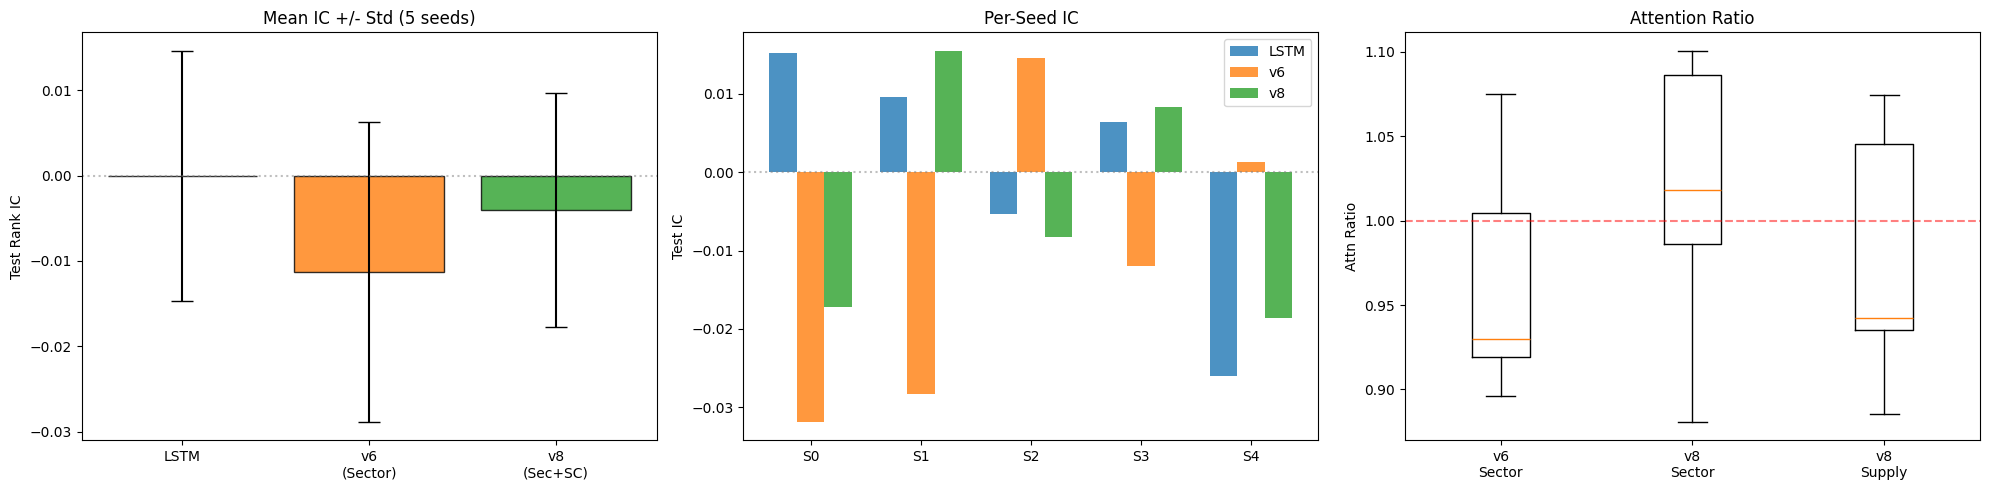

In [13]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# IC bar chart
configs = ["LSTM", "v6\n(Sector)", "v8\n(Sec+SC)"]
means = [m_l, m_6, m_8]; stds = [s_l, s_6, s_8]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
axes[0].bar(configs, means, yerr=stds, capsize=8, color=colors, alpha=0.8, edgecolor="black")
axes[0].axhline(0, color="gray", ls=":", alpha=0.5)
axes[0].set_ylabel("Test Rank IC"); axes[0].set_title(f"Mean IC +/- Std ({N_SEEDS} seeds)")

# Per-seed
x = np.arange(N_SEEDS); w = 0.25
axes[1].bar(x-w, ics_l, w, label="LSTM", color=colors[0], alpha=0.8)
axes[1].bar(x, ics_6, w, label="v6", color=colors[1], alpha=0.8)
axes[1].bar(x+w, ics_8, w, label="v8", color=colors[2], alpha=0.8)
axes[1].axhline(0, color="gray", ls=":", alpha=0.5)
axes[1].set_xticks(x); axes[1].set_xticklabels([f"S{i}" for i in range(N_SEEDS)])
axes[1].set_ylabel("Test IC"); axes[1].set_title("Per-Seed IC"); axes[1].legend()

# Attention ratio box
axes[2].boxplot([ar6, ar8s, ar8c], labels=["v6\nSector", "v8\nSector", "v8\nSupply"])
axes[2].axhline(1.0, color="red", ls="--", alpha=0.5)
axes[2].set_ylabel("Attn Ratio"); axes[2].set_title("Attention Ratio")

plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/3106_Projects/Projects/output/v8/ablation_results.png", dpi=150, bbox_inches="tight")
plt.show()

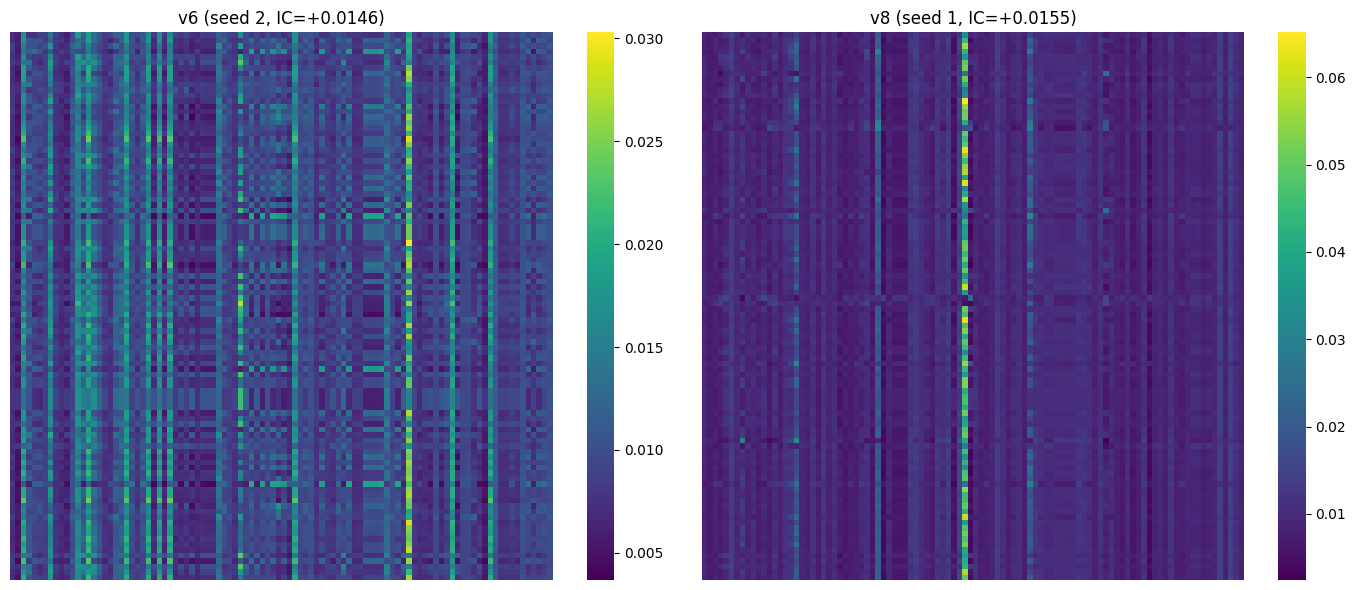

In [14]:
# Attention heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, ver in zip(axes, ["v6", "v8"]):
    a = best_models[ver]["am"][-1][0, 0].cpu().numpy()
    sns.heatmap(a, cmap="viridis", xticklabels=False, yticklabels=False, ax=ax)
    ax.set_title(f"{ver} (seed {best_models[ver]['seed']}, IC={best_models[ver]['ic']:+.4f})")
plt.tight_layout()
plt.savefig(f"/content/drive/MyDrive/3106_Projects/Projects/output/v8/attention_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
# Save JSON
results = {
    "n_seeds": N_SEEDS,
    "aggregate": {
        "lstm": {"ic_mean": m_l, "ic_std": s_l, "mse_mean": mse_l},
        "v6": {"ic_mean": m_6, "ic_std": s_6, "mse_mean": mse_6, "ar_mean": float(np.mean(ar6))},
        "v8": {"ic_mean": m_8, "ic_std": s_8, "mse_mean": mse_8, "ar_sec_mean": float(np.mean(ar8s)), "ar_sup_mean": float(np.mean(ar8c))},
    },
    "per_seed": {k: [dict(r) for r in v] for k, v in ablation.items()},
    "graph": {"sector_edges": n_sec, "supply_edges": n_sup, "v8_alloc": {"sec": m_sec, "sup": m_sup}},
    "best_seeds": {v: best_models[v]["seed"] for v in best_models},
}
for folder in ["v6", "v8"]:
    with open(f"/content/drive/MyDrive/3106_Projects/Projects/output/{folder}/ablation_metrics.json", "w") as f:
        json.dump(results, f, indent=2, default=str)
print(f"Saved to /content/drive/MyDrive/3106_Projects/Projects/output/v6/ and /content/drive/MyDrive/3106_Projects/Projects/output/v8/")

Saved to /content/drive/MyDrive/3106_Projects/Projects/output/v6/ and /content/drive/MyDrive/3106_Projects/Projects/output/v8/
